# Prediction for possible credit defaulters

The dataset is available on [Kaggle](https://www.kaggle.com/datasets/ranadeep/credit-risk-dataset). The target dependant variable is the status of the loan of clients, denomined as 'loan_status'. 

Options are 'Fully Paid', 'Charged Off', 'Current', 'Default', 'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)', 'Does not meet the credit policy. Status:Fully Paid', 'Does not meet the credit policy. Status:Charged Off', 'Issued'. However, we will consider only cases where a final decision has been made and the outcome regarding default is known.

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
#Upload the dataset
bm = pd.read_csv('./loan.csv')
bm[:3] 

#Get some structural info
bm.info() 

C:\Users\rosse\AppData\Local\Temp\ipykernel_13820\2393861915.py:2: DtypeWarning: Columns (19,55) have mixed types. Specify dtype option on import or set low_memory=False.
  bm = pd.read_csv('./loan.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           887379 non-null  int64  
 1   member_id                    887379 non-null  int64  
 2   loan_amnt                    887379 non-null  float64
 3   funded_amnt                  887379 non-null  float64
 4   funded_amnt_inv              887379 non-null  float64
 5   term                         887379 non-null  object 
 6   int_rate                     887379 non-null  float64
 7   installment                  887379 non-null  float64
 8   grade                        887379 non-null  object 
 9   sub_grade                    887379 non-null  object 
 10  emp_title                    835917 non-null  object 
 11  emp_length                   842554 non-null  object 
 12  home_ownership               887379 non-null  object 
 13 

Our target variable is 'loan_status'. However, we would like to remove categories such as 'Current' or 'Issued' from the target, since they don't represent a final outcome (they could still turn out to be either positive or negative), and might therefore introduce noise. We also exclude 'In Grace Period', 'Late (16-30 days)', and 'Late (31-120 days)', since these loans could still be paid off.

In [127]:
#Keep 'bm' as the untouched original dataset; all preprocessing happens on 'cm'
cm = bm.copy()

open_statuses = ['Current', 'Issued', 'In Grace Period', 'Late (16-30 days)', 'Late (31-120 days)']
cm = cm[~cm['loan_status'].isin(open_statuses)]

#Only the definitive statuses are left
default_statuses = ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off']
paid_statuses = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']

#A new target column is now created with a binary outcome
cm['target'] = cm['loan_status'].apply(lambda x: 1 if x in default_statuses else 0) 
print(cm['target'][:5])

#Double-check that no other options are present
cm['loan_status'].unique() 

0    0
1    1
2    0
3    0
5    0
Name: target, dtype: int64


array(['Fully Paid', 'Charged Off', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

## Select the predictor variables
We now focus our attention on selecting the variables that can be used for prediction.

For (some) categorical variables, we compute the default rate (mean of 'target') within each category, and then measure the spread (max - min) across categories. A wide spread suggests the variable is likely predictive, since the default rate varies substantially depending on the category.

In [128]:
#Total default average rate
print(cm['target'].mean())

#Comparing default rates across categorical variables
categ_vars = ['purpose', 'emp_length', 'term', 'home_ownership', 'grade', 'verification_status']

summary = {}
for col in categ_vars:
    rates = cm.groupby(col)['target'].mean()
    summary[col] = rates.max() - rates.min()

pd.Series(summary).sort_values(ascending=False)

0.1838101650586326


grade                  0.348370
home_ownership         0.212291
purpose                0.170180
term                   0.141365
verification_status    0.064796
emp_length             0.015339
dtype: float64

## About variables 'emp_length' and 'verification_status'

In [129]:
print(cm['verification_status'].isna().mean())

print(cm['emp_length'].unique())
print(cm['emp_length'].isna().mean())

cm['emp_length'] = cm['emp_length'].fillna('Missing')

rates = cm.groupby('emp_length')['target'].mean().sort_values(ascending=False)
print(rates)

0.0
['10+ years' '< 1 year' '3 years' '9 years' '4 years' '5 years' '1 year'
 '6 years' '2 years' '7 years' '8 years' nan]
0.03892752754544853
emp_length
Missing      0.261048
9 years      0.190452
7 years      0.189745
< 1 year     0.188931
8 years      0.187796
6 years      0.187233
1 year       0.182091
5 years      0.181888
3 years      0.178795
4 years      0.175917
10+ years    0.175797
2 years      0.175113
Name: target, dtype: float64


- **`emp_length`**: spread jumped from 0.015 to 0.086 once missing values were 
  treated as a `'Missing'` category instead of being silently dropped. The 
  `'Missing'` group (5% of rows) has a 26% default rate vs. 18.4% average — 
  the *absence* of this info is more predictive than the declared value itself.
- **`verification_status`**: no missing values, spread of 0.065 is reliable as-is. 
  A meaningful (35% relative) variation, weaker than `grade` (0.35) but not noise; 
  worth keeping given only 3 categories.

int_rate          0.239584
dti               0.112233
revol_util        0.096587
inq_last_6mths    0.062153
annual_inc       -0.058809
loan_amnt         0.056605
total_acc        -0.032847
delinq_2yrs       0.017466
open_acc          0.010617
pub_rec           0.003506
revol_bal        -0.002653
Name: target, dtype: float64


Text(0.5, 1.0, 'Correlation')

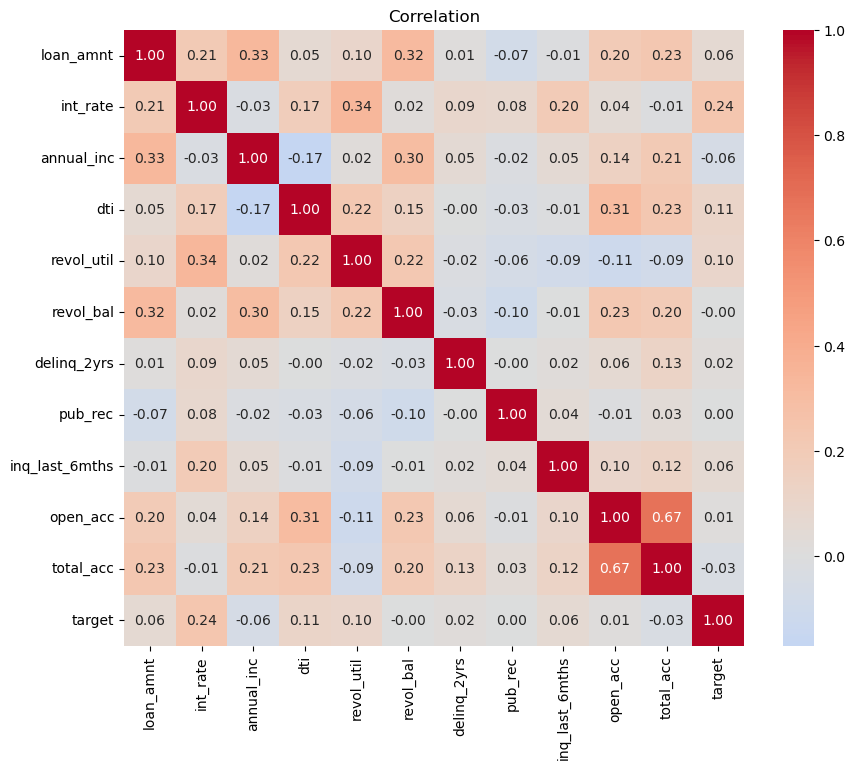

In [130]:
num_vars = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'revol_bal', 'delinq_2yrs', 'pub_rec', 'inq_last_6mths', 'open_acc', 'total_acc']

#Check correlation with the target - compute Pearson correlation matrix
correlations = cm[num_vars + ['target']].corr()['target'].drop('target')
print(correlations.sort_values(key=abs, ascending=False))

#Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = cm[num_vars + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation')

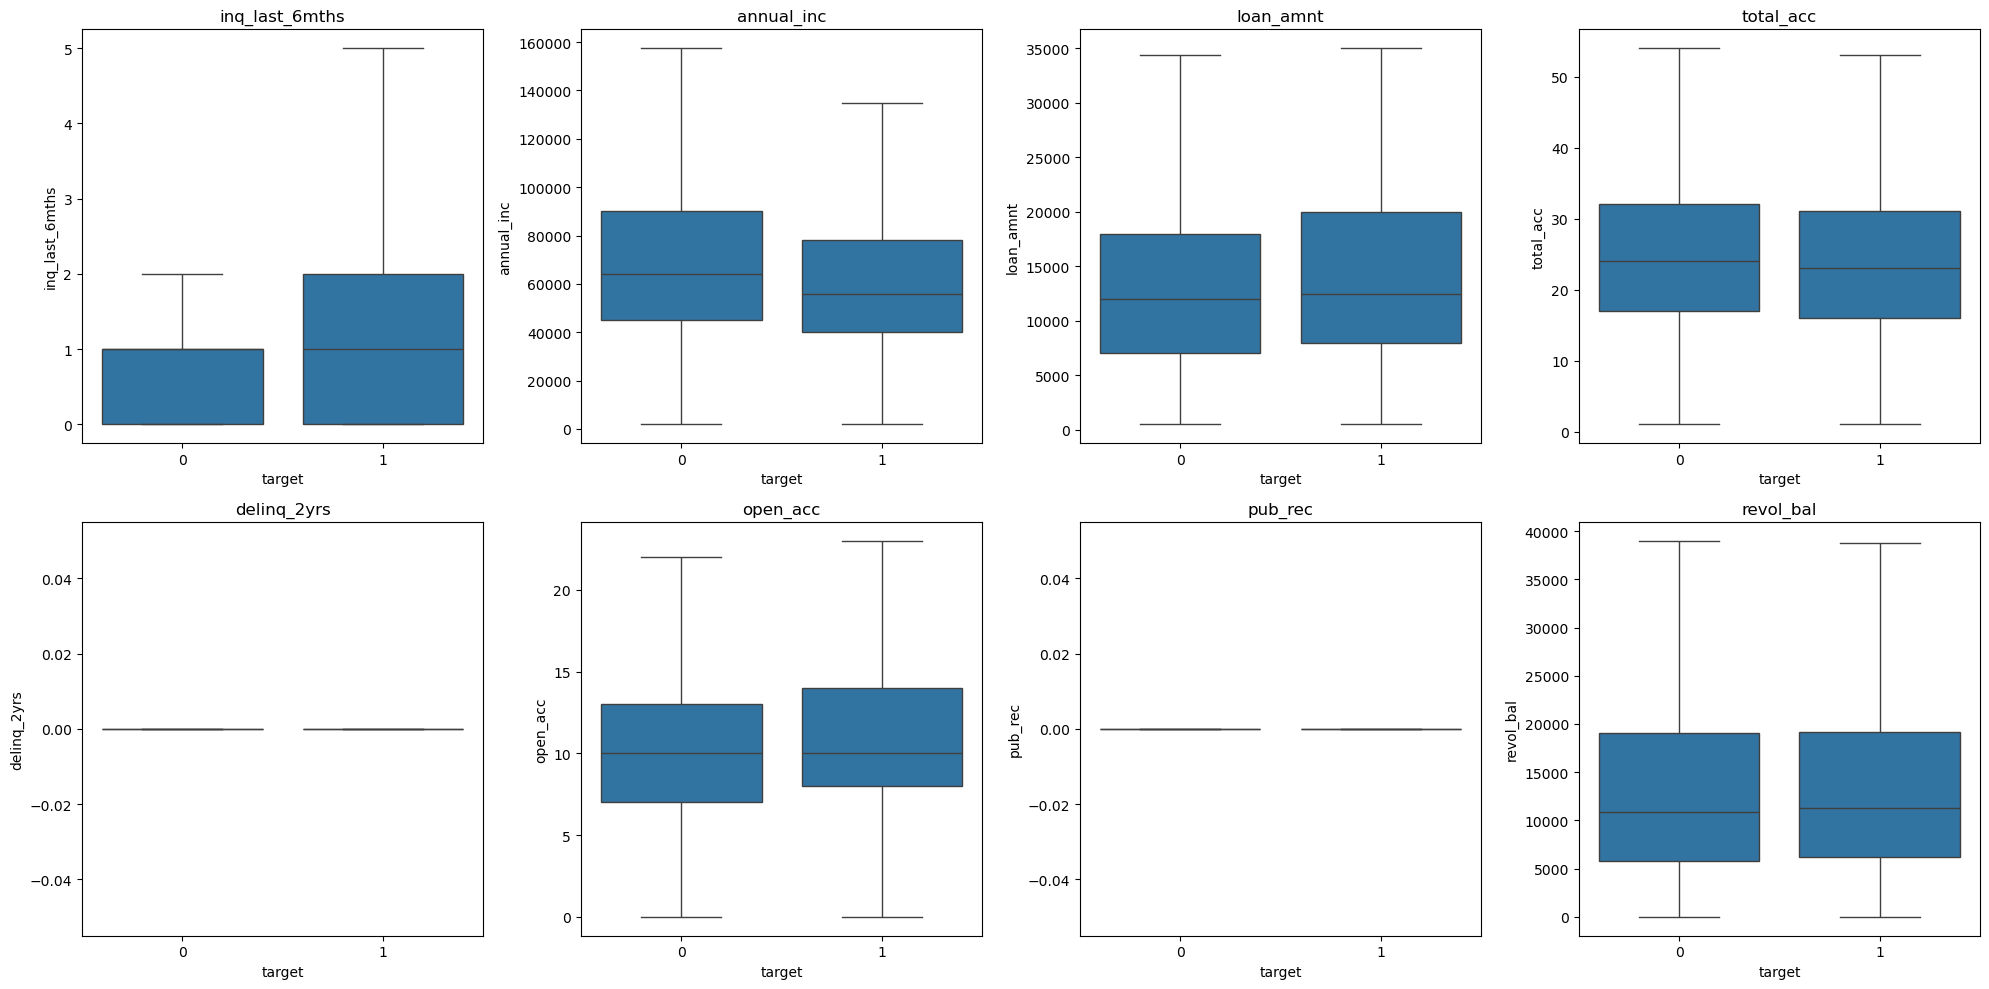

In [131]:
low_corr_vars = ['inq_last_6mths', 'annual_inc', 'loan_amnt', 'total_acc', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(low_corr_vars):
    sns.boxplot(data=cm, x='target', y=col, ax=axes[i], showfliers=False)
    axes[i].set_title(f'{col}')

plt.tight_layout()

We exclude
- **'total_acc'**: no pattern, neither linear nor visual. Plus strong correlation with 'open_acc'
- **'open_acc'**: no clear pattern. Plus strong correlation with 'total_acc'
- **'revol_bal'**: no relevant pattern

For 'delinq_2yrs' and 'pub_rec' we do not deduce enough information from the boxplots. They are highly concentrated at zero, so we use binary indicators.

In [132]:
cm['has_delinq'] = (cm['delinq_2yrs'] > 0).astype(int)
cm['has_pub_rec'] = (cm['pub_rec'] > 0).astype(int)

print(cm.groupby('has_delinq')['target'].mean())
print(cm.groupby('has_pub_rec')['target'].mean())

has_delinq
0    0.181216
1    0.197319
Name: target, dtype: float64
has_pub_rec
0    0.183559
1    0.185611
Name: target, dtype: float64


'has_delinq' shows a small increase in default rate (18.12% -> 19.73%), suggesting some predictive value.
'has_pub_rec' shows almost no difference (18.36% -> 18.56%), suggesting very weak predictive value.
For this reason, we discard 'has_pub_rec'.

In [133]:
from sklearn.model_selection import train_test_split 

new_num_vars = [v for v in num_vars if v not in ['total_acc', 'open_acc', 'revol_bal', 'delinq_2yrs', 'pub_rec']]
new_num_vars += ['has_delinq']

predictors = categ_vars + new_num_vars

#Transform categorical variables in numerical
X = pd.get_dummies(cm[predictors], columns=categ_vars, drop_first=True)
Y = cm['target']

# Generate TRAINING e TEST sets
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, stratify=Y)
#stratify to keep the default average proportioned in train and test


In [134]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, mean_absolute_error, mean_squared_error, r2_score

def PrintEvaluation(y_test, y_pred):
    try:
        print('MAE:', mean_absolute_error(y_test, y_pred))
        print('MSE:', mean_squared_error(y_test, y_pred))
        print('R2:', r2_score(y_test, y_pred))    
        print('ACCURACY:', accuracy_score(y_test, y_pred))
        print('REPORT:',classification_report(y_test, y_pred))
        print('CM:', confusion_matrix(y_test, y_pred))
    except:
        print('Computational error: Debug the code')

In [ ]:
#Check NaN values because Logistic Regression does not accept them
print(x_train.isna().sum().sort_values(ascending=False))

revol_util                             185
inq_last_6mths                          19
annual_inc                               3
loan_amnt                                0
home_ownership_OTHER                     0
emp_length_7 years                       0
emp_length_8 years                       0
emp_length_9 years                       0
emp_length_< 1 year                      0
emp_length_Missing                       0
term_ 60 months                          0
home_ownership_MORTGAGE                  0
home_ownership_NONE                      0
home_ownership_RENT                      0
home_ownership_OWN                       0
emp_length_5 years                       0
grade_B                                  0
grade_C                                  0
grade_D                                  0
grade_E                                  0
grade_F                                  0
grade_G                                  0
verification_status_Source Verified      0
emp_length_

In [136]:
# Handle missing values by replacing them with the median calculated from the training set.
# The same median values are then applied to the test set to avoid data leakage.
w_train = x_train.copy()
w_test = x_test.copy()
for col in new_num_vars:
    median = x_train[col].median()
    w_train[col] = w_train[col].fillna(median)
    w_test[col] = w_test[col].fillna(median)

print(w_train.isna().sum().sort_values(ascending=False))

loan_amnt                              0
emp_length_4 years                     0
emp_length_6 years                     0
emp_length_7 years                     0
emp_length_8 years                     0
emp_length_9 years                     0
emp_length_< 1 year                    0
emp_length_Missing                     0
term_ 60 months                        0
home_ownership_MORTGAGE                0
home_ownership_NONE                    0
home_ownership_OTHER                   0
home_ownership_OWN                     0
home_ownership_RENT                    0
grade_B                                0
grade_C                                0
grade_D                                0
grade_E                                0
grade_F                                0
grade_G                                0
verification_status_Source Verified    0
emp_length_5 years                     0
emp_length_3 years                     0
int_rate                               0
emp_length_2 yea

In [137]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

z_train = w_train.copy()
z_test = w_test.copy()


z_train[new_num_vars] = scaler.fit_transform(z_train[new_num_vars])
z_test[new_num_vars] = scaler.transform(z_test[new_num_vars])

## Logistic Regression

In [138]:
from sklearn.linear_model import LogisticRegression

def RunLogisticRegression(x_train, x_test, y_train):
    logit = LogisticRegression(penalty='l2', class_weight='balanced', max_iter=2000) 
    
    logit.fit(x_train, y_train)
    y_pred = logit.predict_proba(x_test) 
    y_pred = [1 if p[0] < p[1] else 0 for p in y_pred]
    
    return y_pred
    
y_pred = RunLogisticRegression(z_train, z_test, y_train)
PrintEvaluation(y_test, y_pred)

MAE: 0.36195220674087336
MSE: 0.36195220674087336
R2: -1.4126361547357873
ACCURACY: 0.6380477932591266
REPORT:               precision    recall  f1-score   support

           0       0.89      0.63      0.74     52428
           1       0.29      0.66      0.40     11807

    accuracy                           0.64     64235
   macro avg       0.59      0.65      0.57     64235
weighted avg       0.78      0.64      0.68     64235

CM: [[33151 19277]
 [ 3973  7834]]


## Nearest Neighbours

In [139]:
from sklearn import neighbors

def RunNeighborClassifier(x_train, x_test, y_train):
    knn = neighbors.KNeighborsClassifier(n_neighbors=5)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    return y_pred

y_pred = RunNeighborClassifier(z_train, z_test, y_train)
PrintEvaluation(y_test, y_pred)

MAE: 0.20853117459329026
MSE: 0.20853117459329026
R2: -0.38998973301874695
ACCURACY: 0.7914688254067097
REPORT:               precision    recall  f1-score   support

           0       0.83      0.94      0.88     52428
           1       0.33      0.13      0.19     11807

    accuracy                           0.79     64235
   macro avg       0.58      0.54      0.53     64235
weighted avg       0.74      0.79      0.75     64235

CM: [[49296  3132]
 [10263  1544]]


In [140]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

params = {'n_neighbors': [3, 5, 7, 9, 11, 15, 21]}

grid = GridSearchCV(knn,params,cv=3,scoring='f1', n_jobs=-1)

grid.fit(z_train, y_train)

print('Best n:', grid.best_params_)
print('Best F1:', grid.best_score_)

y_pred = grid.predict(z_test)
PrintEvaluation(y_test, y_pred)

Best n: {'n_neighbors': 3}
Best F1: 0.21163139357489538
MAE: 0.225640227290418
MSE: 0.225640227290418
R2: -0.5040321903974407
ACCURACY: 0.774359772709582
REPORT:               precision    recall  f1-score   support

           0       0.83      0.91      0.87     52428
           1       0.30      0.17      0.22     11807

    accuracy                           0.77     64235
   macro avg       0.57      0.54      0.54     64235
weighted avg       0.73      0.77      0.75     64235

CM: [[47707  4721]
 [ 9773  2034]]


## Gradient Boosting

In [141]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=0, class_weight='balanced')

params = {'max_iter': [100, 150],        #number of decisional trees
          'learning_rate': [0.05, 0.1],
          'max_depth': [2, 3]}            #maximal tree complexity

grid = GridSearchCV(hgb, params, cv=3, scoring='f1', n_jobs=-1)
grid.fit(w_train, y_train)

print('Best parameters:', grid.best_params_)
print('Best F1:', grid.best_score_)

y_pred = grid.predict(w_test)
PrintEvaluation(y_test, y_pred)

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 150}
Best F1: 0.40456793572551386
MAE: 0.3608157546508913
MSE: 0.3608157546508913
R2: -1.4050609960564016
ACCURACY: 0.6391842453491088
REPORT:               precision    recall  f1-score   support

           0       0.89      0.63      0.74     52428
           1       0.29      0.67      0.40     11807

    accuracy                           0.64     64235
   macro avg       0.59      0.65      0.57     64235
weighted avg       0.78      0.64      0.68     64235

CM: [[33204 19224]
 [ 3953  7854]]


For these classification models, we focus on recall and F1-score (rather than 
accuracy alone) for the default class, since the dataset is imbalanced and 
accuracy can be misleading — a model that mostly predicts the majority class 
would still score high on accuracy while failing at the actual goal of 
identifying defaulters.

Logistic Regression and Gradient Boosting perform nearly identically on the default class (f1-score around 0.40, recall 66-67%), trading lower overall accuracy (64%) for much better detection of defaulters. KNN reaches higher accuracy (77%) but misses around 83% of true defaulters (recall 0.17, f1-score 0.22) — a clear case of accuracy being misleading on an imbalanced dataset, likely because KNN, 
unlike the other two models, was not trained with class balancing. Logistic Regression and Gradient Boosting are therefore the preferable models for this task.